Clean and Rank the Results

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
import pandas as pd

df = pd.read_csv("/content/drive/MyDrive/Alzheimer_AI_Virtual_Screening/Results/Docking_Results.csv")
df.head()

,Ligand,Binding Energy (kcal/mol)
0,EGCG,-11.972
1,Donepezil,-11.771
2,Demethoxycurcumin,-10.948
3,Curcumin,-10.932
4,Bisdemethoxycurcumin,-10.749


In [ ]:
df.info()
df.describe()
df.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 41 entries, 0 to 40
Data columns (total 2 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   Ligand                     41 non-null     object 
 1   Binding Energy (kcal/mol)  41 non-null     float64
dtypes: float64(1), object(1)
memory usage: 788.0+ bytes


,0
Ligand,0
Binding Energy (kcal/mol),0


In [ ]:
df = df.sort_values(
    by="Binding Energy (kcal/mol)",
    ascending=True
)

df

,Ligand,Binding Energy (kcal/mol)
0,EGCG,-11.972
1,Donepezil,-11.771
2,Demethoxycurcumin,-10.948
3,Curcumin,-10.932
4,Bisdemethoxycurcumin,-10.749
5,Hesperidin,-10.739
6,Rosmarinic acid,-10.675
7,Baicalein,-10.570
8,Ellagic acid,-10.447
9,Chrysin,-10.411


Assign ranking

In [ ]:
df["Rank"] = range(1, len(df)+1)

In [ ]:
df.to_csv(
    "Ranked_Docking_Results.csv",
    index=False
)

#Visualization

Horizontal bar chart

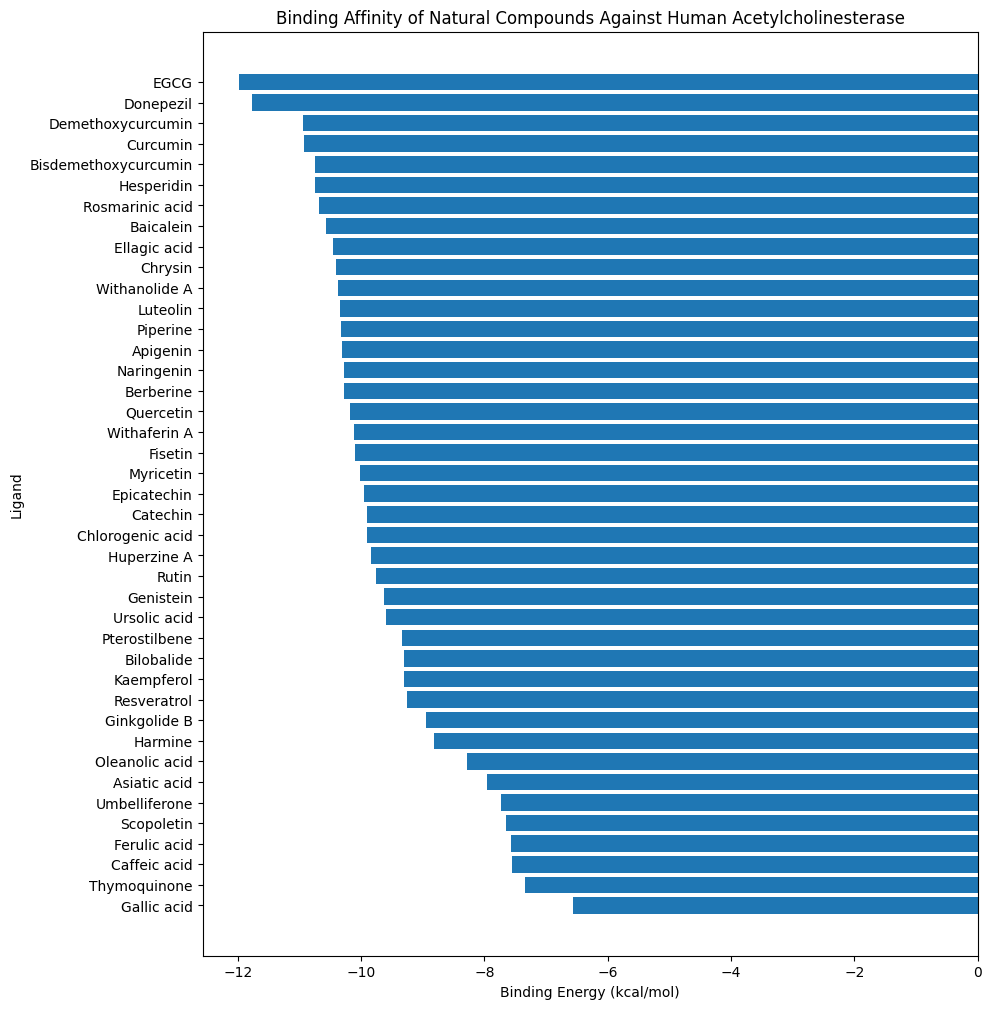

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,12))

plt.barh(
    df["Ligand"],
    df["Binding Energy (kcal/mol)"]
)

plt.xlabel("Binding Energy (kcal/mol)")
plt.ylabel("Ligand")
plt.title("Binding Affinity of Natural Compounds Against Human Acetylcholinesterase")

plt.gca().invert_yaxis()

plt.show()

Descriptive Statistics

In [ ]:
df["Binding Energy (kcal/mol)"].describe()

,Binding Energy (kcal/mol)
count,41.000000
mean,-9.650805
std,1.227737
min,-11.972000
25%,-10.370000
50%,-9.955000
75%,-9.246000
max,-6.557000


Distribution of Binding Energies

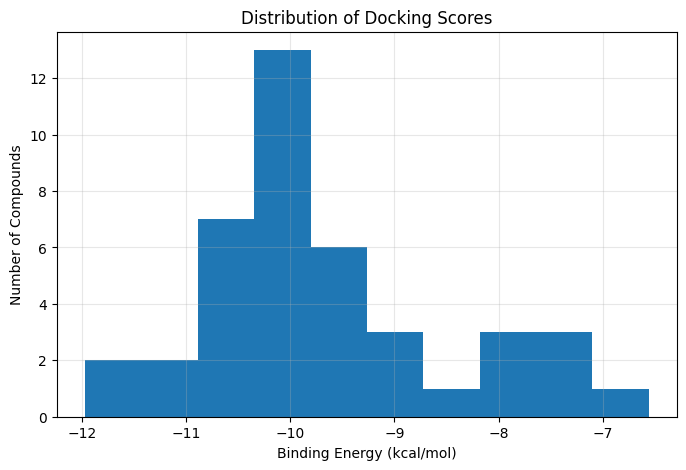

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

plt.hist(df["Binding Energy (kcal/mol)"], bins=10)

plt.xlabel("Binding Energy (kcal/mol)")
plt.ylabel("Number of Compounds")
plt.title("Distribution of Docking Scores")

plt.grid(alpha=0.3)

plt.show()

Box Plot

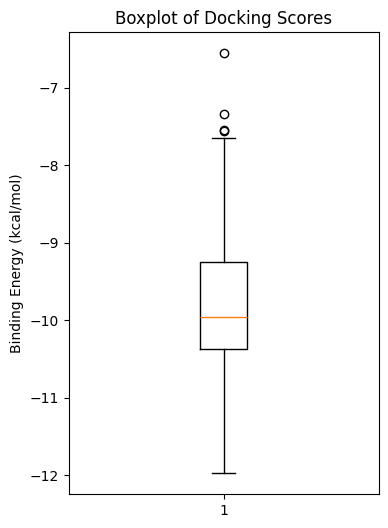

In [ ]:
plt.figure(figsize=(4,6))

plt.boxplot(df["Binding Energy (kcal/mol)"])

plt.ylabel("Binding Energy (kcal/mol)")
plt.title("Boxplot of Docking Scores")

plt.show()

Categorize Ligands

In [ ]:
def category(score):
    if score <= -10:
        return "Excellent"
    elif score <= -9:
        return "Very Good"
    elif score <= -8:
        return "Good"
    else:
        return "Moderate"

df["Category"] = df["Binding Energy (kcal/mol)"].apply(category)

In [ ]:
df["Category"].value_counts()

,count
Category,
Excellent,20
Very Good,11
Moderate,7
Good,3


Category Pie Chart

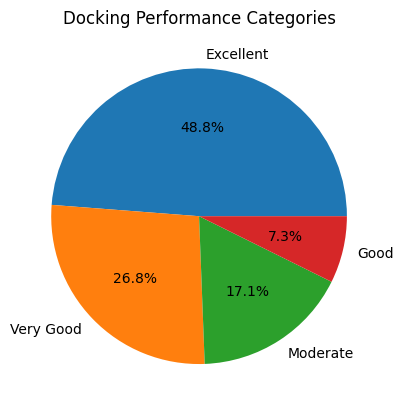

In [ ]:
df["Category"].value_counts().plot(
    kind="pie",
    autopct="%1.1f%%"
)

plt.ylabel("")
plt.title("Docking Performance Categories")

plt.show()

Identify Lead Compounds

In [ ]:
lead = df[df["Binding Energy (kcal/mol)"] <= -10]

lead

,Ligand,Binding Energy (kcal/mol),Rank,Category
0,EGCG,-11.972,1,Excellent
1,Donepezil,-11.771,2,Excellent
2,Demethoxycurcumin,-10.948,3,Excellent
3,Curcumin,-10.932,4,Excellent
4,Bisdemethoxycurcumin,-10.749,5,Excellent
5,Hesperidin,-10.739,6,Excellent
6,Rosmarinic acid,-10.675,7,Excellent
7,Baicalein,-10.570,8,Excellent
8,Ellagic acid,-10.447,9,Excellent
9,Chrysin,-10.411,10,Excellent


In [ ]:
lead.to_csv("Lead_Compounds.csv", index=False)